**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - evaluate model on the test set
    - plot ROC-AUC curve
2. Assess the performance of Random Forest, which is trained on system properties only
3. Creare dataframe with the main performance indicators


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GridSearchCV, GroupShuffleSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, roc_curve, recall_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

First, let's import datasets, target and groups. We remove all molecular descriptors from features (everything except first four columns)

In [2]:
with open('X_padel.pickle', 'rb') as input:
    X_padel = pickle.load(input)

X_padel = X_padel.iloc[:, :4]

In [3]:
with open('y.pickle', 'rb') as input:
    target = pickle.load(input)


In [4]:
with open('groups.pickle', 'rb') as input:
    groups = pickle.load(input)

Only one set is retained as they actually don't differ in system properties

In [12]:
descriptors_dict = {'Padel':X_padel}

Here we instantiate a dictionary, that weill contain performance metrics

In [26]:
scores = {'Descriptors':[], 'Full or PCA':[], 'Presicion_CV':[], 'Stddev_CV':[], 'Accuracy':[], 'F1 - score':[], 'ROC-AUC Score':[], 'Estimator':[], 'Recall score':[], 'Precision score':[]}

The function below performs multiple tasks:
1. First, it create matplotlib figure object and axes with two fields,
2. Then for the one feature set we:
    - Split dataset into training and testing subsets in a structure-based manner;
    - Instantiate a pipeline with parameters provided by HyperOpt;
    - Search for optimal parameters that yield minimum negative mean CV precision using [hyperopt package](http://hyperopt.github.io/hyperopt/). Search is made over 50 iterations;
    - Extract the best hyperparameters and train model on X_train and y_train;
    - Calculate different metrics (Precision, Accuracy, F1-Score, ROC_AUC score) on the test set and append them to the "Scores" dictionary, as well as some information abour descriptors sets and name of the algorithm
    - Finally, plot ROC-AUC curves and save them to folder

In [16]:
def calculate_to_score(pipe, estimator_name, param_grid, descriptors_dict = descriptors_dict, target=target, type = 'Full', groups = groups):
    fig, axes = plt.subplots(1, 2, figsize = (26,12))
    i = 0
    for key, value in descriptors_dict.items():
        splitter = GroupShuffleSplit(n_splits=2, random_state = 0)
        split = splitter.split(X = value, y = target, groups = groups)
        train_indices, test_indices = next(split)
        X_train, y_train, groups_train = value.iloc[train_indices], target.iloc[train_indices], groups[train_indices]
        X_test, y_test, groups_test = value.iloc[test_indices], target.iloc[test_indices], groups[test_indices]       
        cv = StratifiedGroupKFold(n_splits = 10)
        def objective(params, X, target, groups_train):
            #pipe = make_pipeline(MinMaxScaler(), estimator)
            pipe.set_params(**params)
            score = cross_val_score(pipe, X, target, cv = cv, groups = groups_train, scoring = 'precision')
            
            return {'loss':-score.mean(), 'stddev':score.std(),  'status':STATUS_OK, 'Trained_model':pipe}
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train, groups_train = groups_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  50)
        print(best)
        best_model_and_properties = get_best_model_from_trials(trials)

        
        print('Loss is {}'.format(best_model_and_properties[2]))
        print('Standard deviation is {}'.format(best_model_and_properties[1]))
        best_estimator  = best_model_and_properties[0]
        scores['Presicion_CV'].append(best_model_and_properties[2])
        scores['Stddev_CV'].append(best_model_and_properties[1])


        
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        probs = best_estimator.predict_proba(X_test)[:,1]
        scores['Descriptors'].append(key)
        scores['Accuracy'].append(accuracy_score(y_test, predictions))
        scores['F1 - score'].append(f1_score(y_test, predictions))
        scores['ROC-AUC Score'].append(roc_auc_score(y_test, probs))
        scores['Recall score'].append(recall_score(y_test, predictions))
        scores['Precision score'].append(precision_score(y_test, predictions))
        scores['Full or PCA'].append(type)
        scores['Estimator'].append(estimator_name)
        fpr, tpr, _ = roc_curve(y_test, probs)
        axes[i].plot(fpr, tpr)
        axes[i].plot([0,1],[0,1], 'k--')
        axes[i].set_title('ROC-AUC Curve for {} descriptors'.format(key))
        axes[i].set_xlabel('False positive rate')
        axes[i].set_ylabel('True positive rate')
        i += 1
    plt.tight_layout()
    plt.savefig('ROC_AUC_all_temps_structure_based/'+estimator_name+'_'+type+'.png')

Subfunction below is made to retrieve best model from Trials object ans is used in main function

In [18]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']['Trained_model'], best_trial_obj['result']['stddev'], -best_trial_obj['result']['loss']

Here we will try only one algorithm -
**Random Forest Classification** 

In [28]:
pipe = Pipeline([('varsel', VarianceThreshold()),('randomforest', RandomForestClassifier(n_jobs = -1))])

In [30]:
space={'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
    'randomforest__max_depth':hp.randint('max_depth',1,50),  'randomforest__max_features':hp.choice('max_features', [None, 'sqrt', 'log2']),
       'randomforest__min_samples_split':hp.randint('min_samples_split', 2, 8),
       'randomforest__min_samples_leaf': hp.randint('min_samples_leaf', 1, 10),
      'randomforest__n_estimators':hp.randint('n_estimators',50, 500),
      'randomforest__criterion': hp.choice('criterion', ["gini", "entropy", "log_loss"])}

100%|███████████████████████████████████████████████| 50/50 [07:37<00:00,  9.16s/trial, best loss: -0.7834156768378369]
{'criterion': 0, 'max_depth': 12, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 408, 'threshold': 0.19421098613380702}
Loss is 0.7834156768378369
Standard deviation is 0.10362103662302509


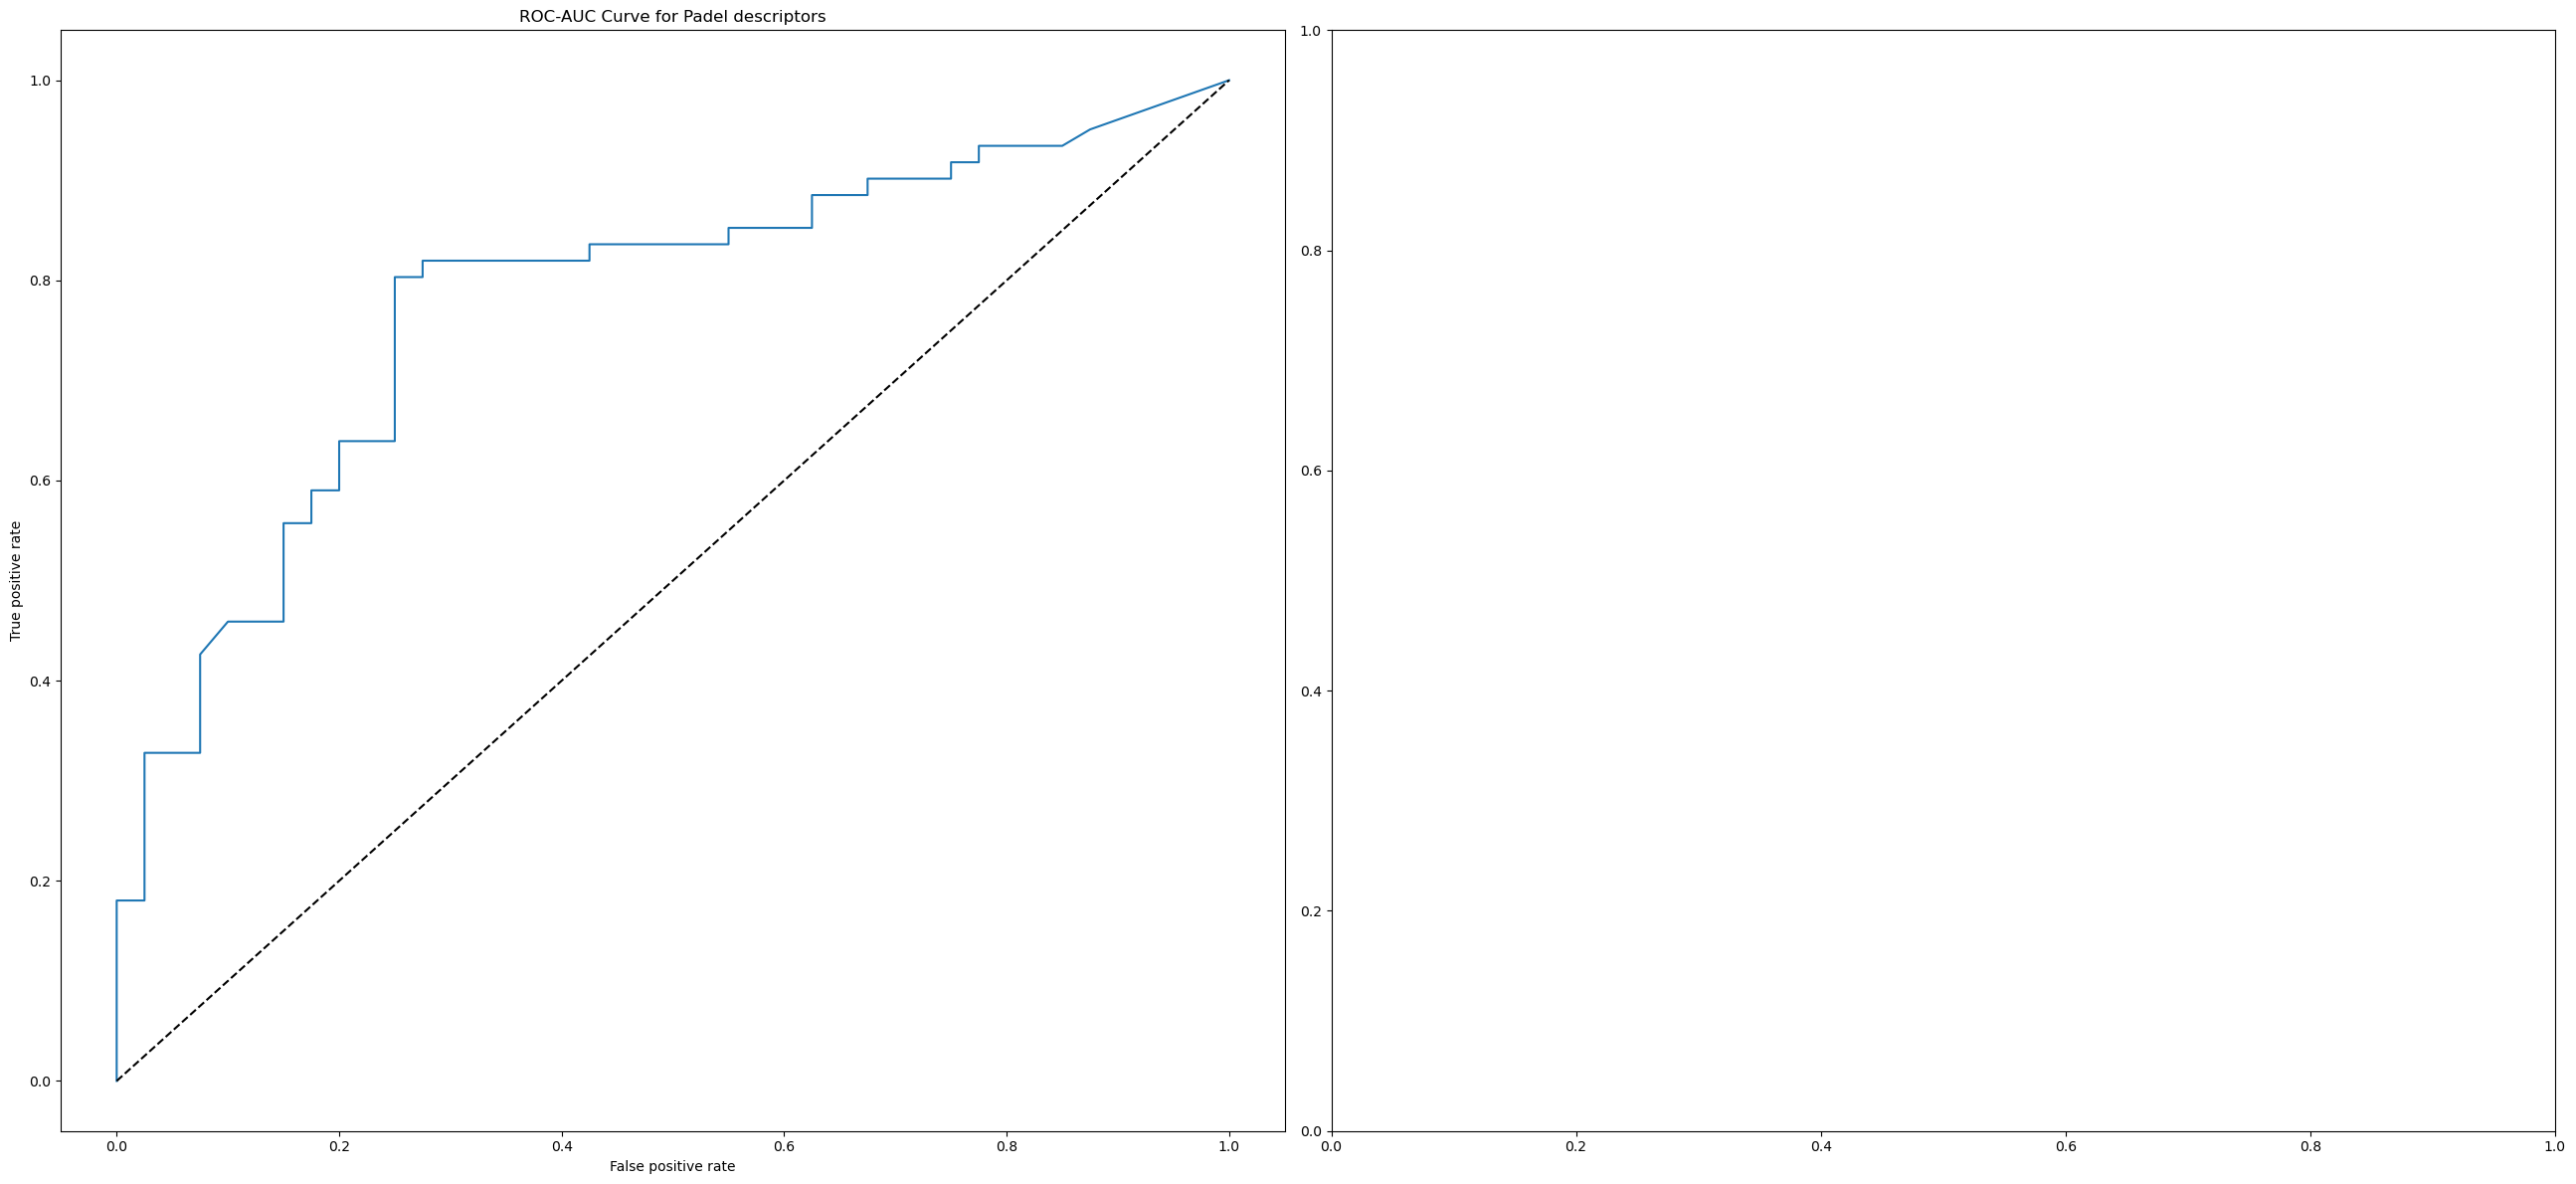

In [32]:
calculate_to_score(pipe, estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict,
                   target=target,type = 'Full')
               

Let's see evaluation results

In [33]:
pd.DataFrame(scores)

,Descriptors,Full or PCA,Presicion_CV,Stddev_CV,Accuracy,F1 - score,ROC-AUC Score,Estimator,Recall score,Precision score
0,Padel,Full,0.783416,0.103621,0.663366,0.666667,0.777459,Random Forest,0.557377,0.829268
